All libraries imported successfully!
Dataset loaded: 2000 rows x 18 columns

Columns:
['Engineering_Branch', 'Student_Status', 'CGPA', 'Python_Proficiency', 'CPP_Proficiency', 'Java_Proficiency', 'MATLAB_Proficiency', 'DSA_Understanding', 'Database_SQL_Understanding', 'OOP_Understanding', 'OS_Understanding', 'Technical_Tools', 'Project_Count', 'Project_Domain', 'Internship_Experience', 'Preparation_Domain', 'Confidence_Level', 'Job_Role']
EXPLORATORY DATA ANALYSIS

--- Dataset Info ---
Shape: (2000, 18)

Missing Values:
Engineering_Branch            0
Student_Status                0
CGPA                          6
Python_Proficiency            0
CPP_Proficiency               0
Java_Proficiency              0
MATLAB_Proficiency            0
DSA_Understanding             0
Database_SQL_Understanding    0
OOP_Understanding             0
OS_Understanding              0
Technical_Tools               0
Project_Count                 0
Project_Domain                0
Internship_Experience     

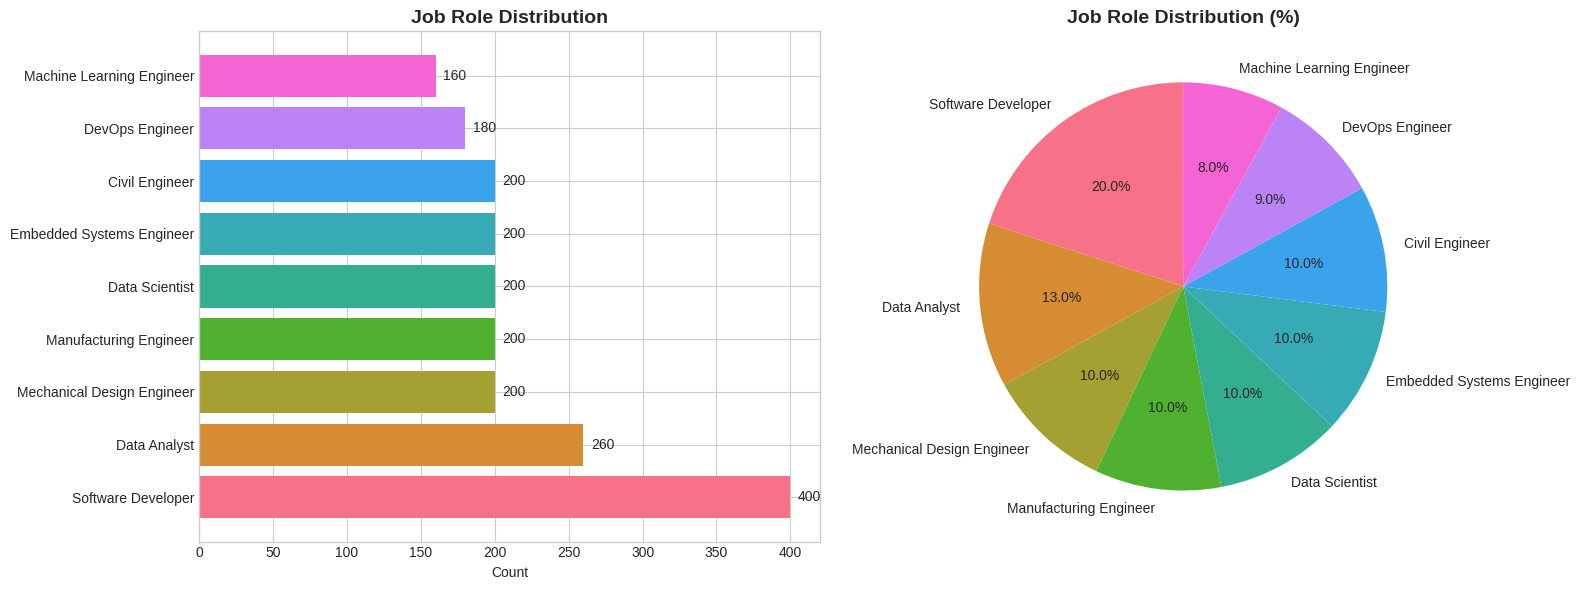

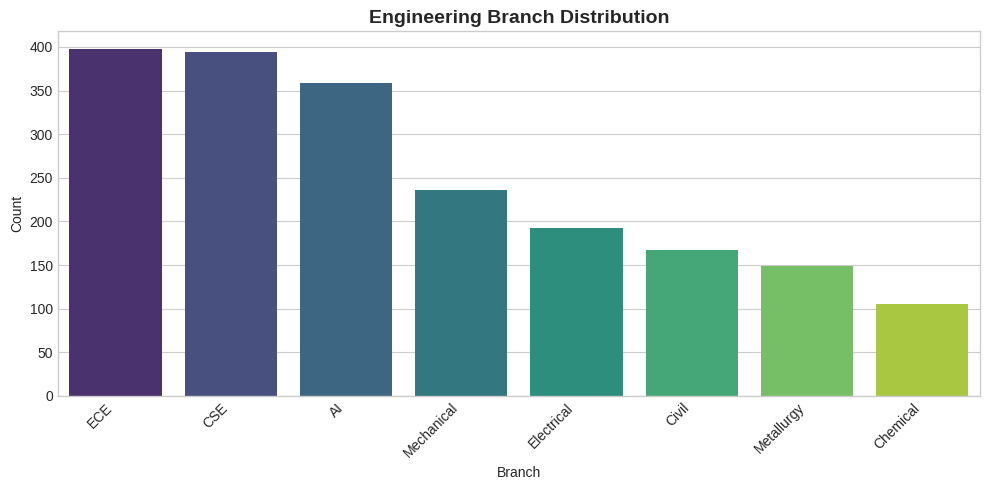

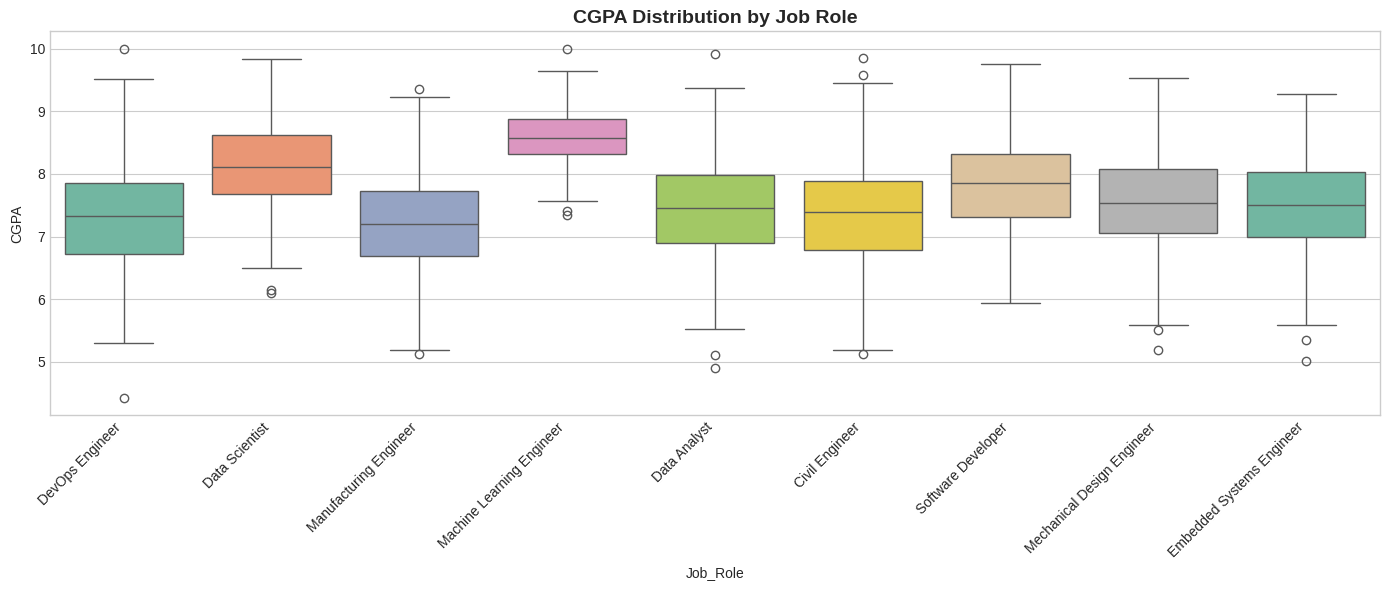

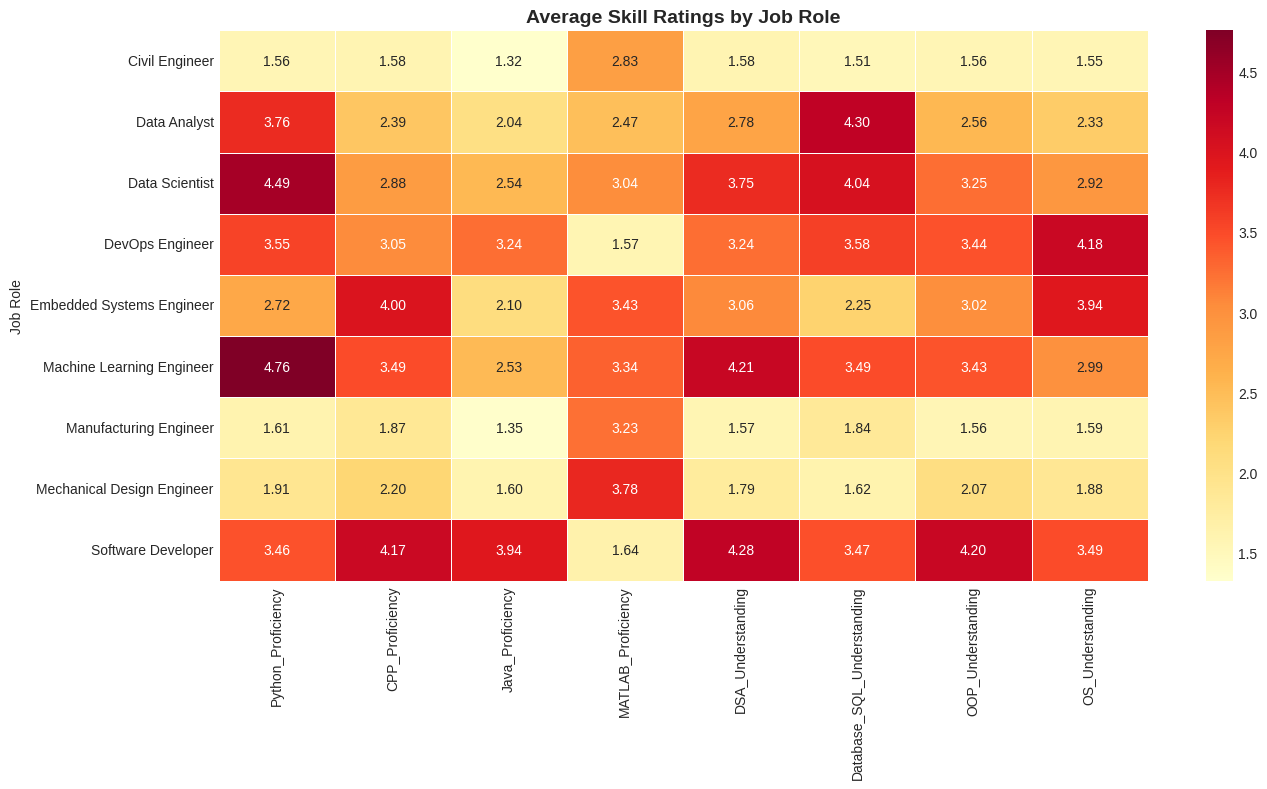

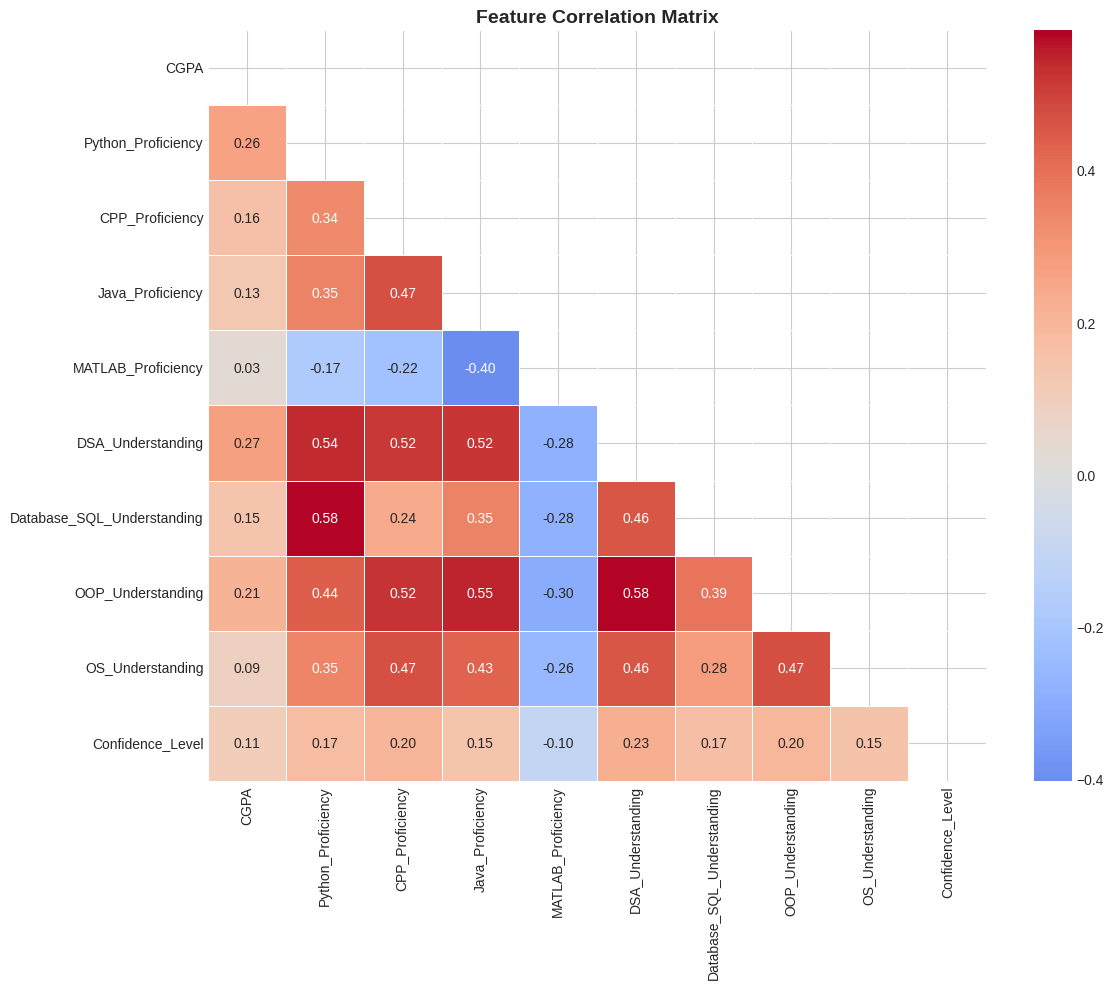

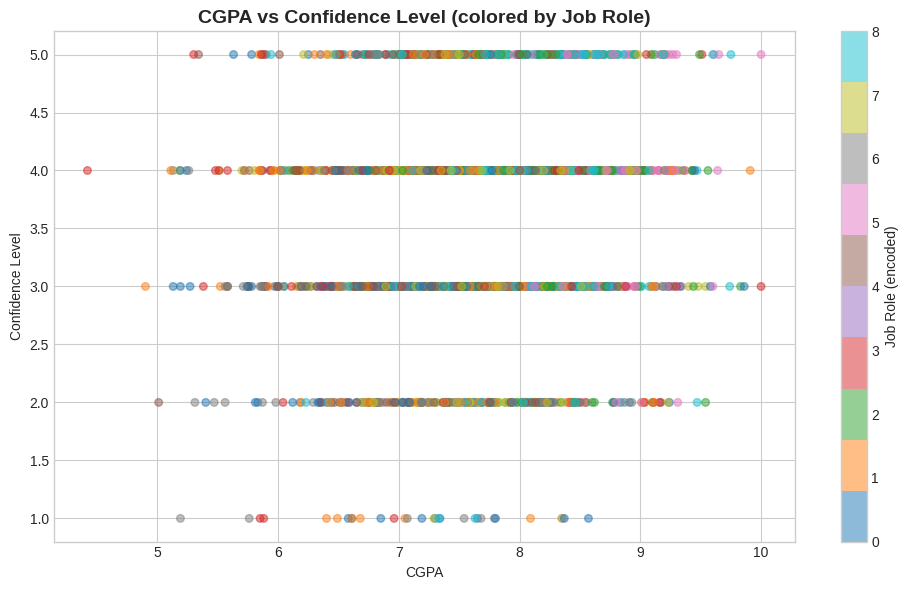


EDA Complete! All plots saved.

DATA PREPROCESSING

--- Handling Missing Values ---
Before: 10 missing values
After:  0 missing values

--- Encoding Technical Tools (Multi-Label) ---
Created 8 binary tool columns

--- Label Encoding Categorical Features ---
  Engineering_Branch: {'AI': np.int64(0), 'CSE': np.int64(1), 'Chemical': np.int64(2), 'Civil': np.int64(3), 'ECE': np.int64(4), 'Electrical': np.int64(5), 'Mechanical': np.int64(6), 'Metallurgy': np.int64(7)}
  Student_Status: {'4th year student': np.int64(0), 'Alumni (Graduated)': np.int64(1)}
  Project_Count: {'0': np.int64(0), '1-2': np.int64(1), '3-4': np.int64(2), '5+': np.int64(3)}
  Project_Domain: {'Core Engineering': np.int64(0), 'Data Science / AI': np.int64(1), 'Mixed domains': np.int64(2), 'Robotics / Embedded Systems': np.int64(3), 'Software Development': np.int64(4)}
  Internship_Experience: {'Core Engineering Internship': np.int64(0), 'Data Science / AI Internship': np.int64(1), 'Electronics / Embedded Internship': 

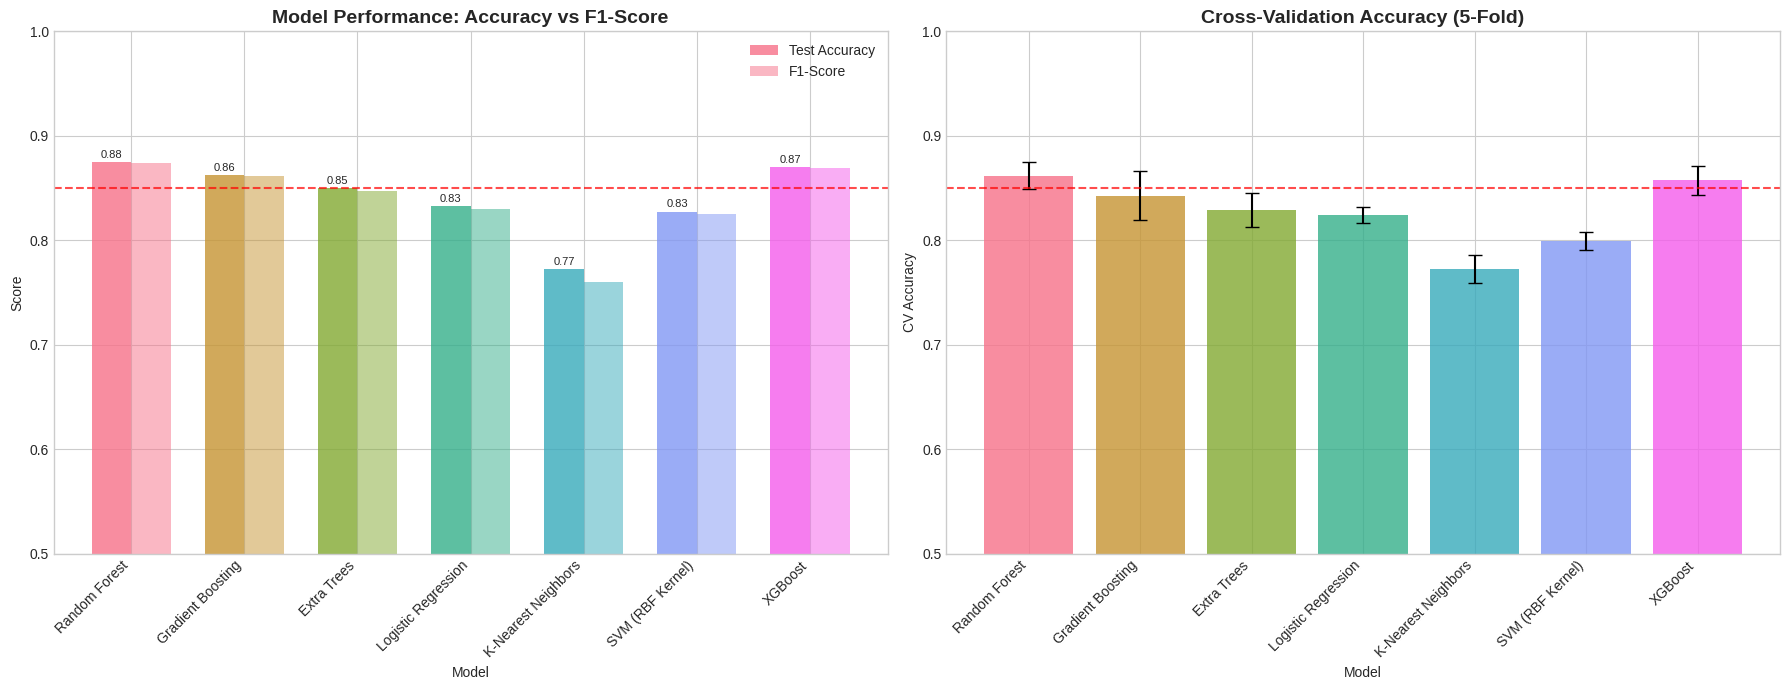

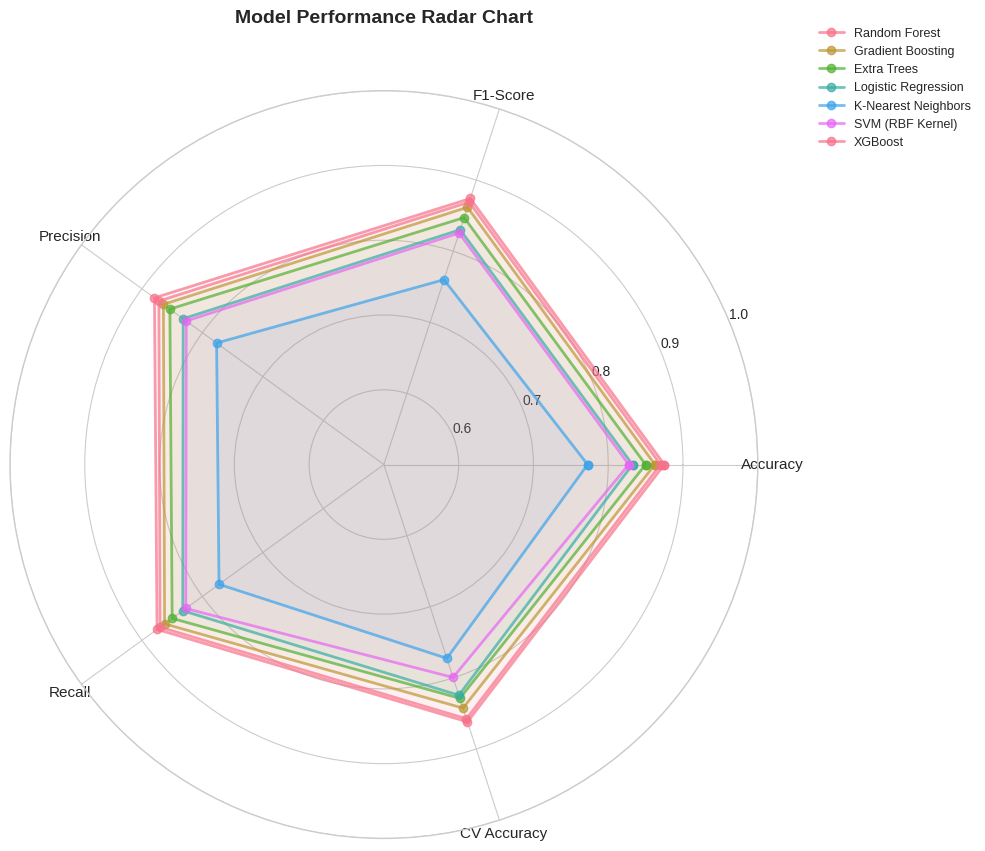


BEST MODEL ANALYSIS

Best Model: 1. Random Forest
  Accuracy:    0.8750
  F1-Score:    0.8741
  CV Accuracy: 0.8619

--- Classification Report (1. Random Forest) ---
                            precision    recall  f1-score   support

            Civil Engineer       0.76      0.72      0.74        40
              Data Analyst       0.94      0.92      0.93        52
            Data Scientist       0.77      0.93      0.84        40
           DevOps Engineer       0.94      0.92      0.93        36
 Embedded Systems Engineer       1.00      1.00      1.00        40
 Machine Learning Engineer       0.96      0.78      0.86        32
    Manufacturing Engineer       0.76      0.62      0.68        40
Mechanical Design Engineer       0.73      0.90      0.81        40
        Software Developer       0.96      0.96      0.96        80

                  accuracy                           0.88       400
                 macro avg       0.87      0.86      0.86       400
              w

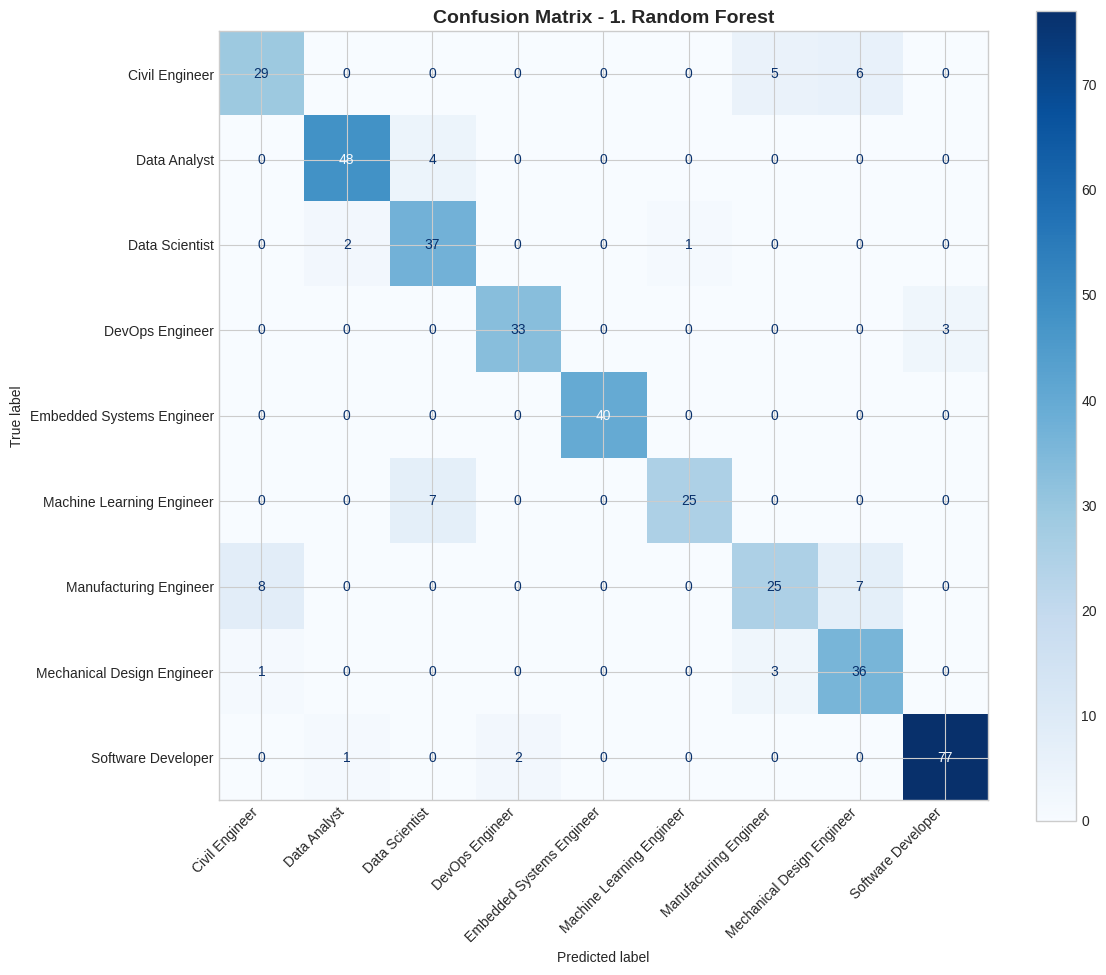

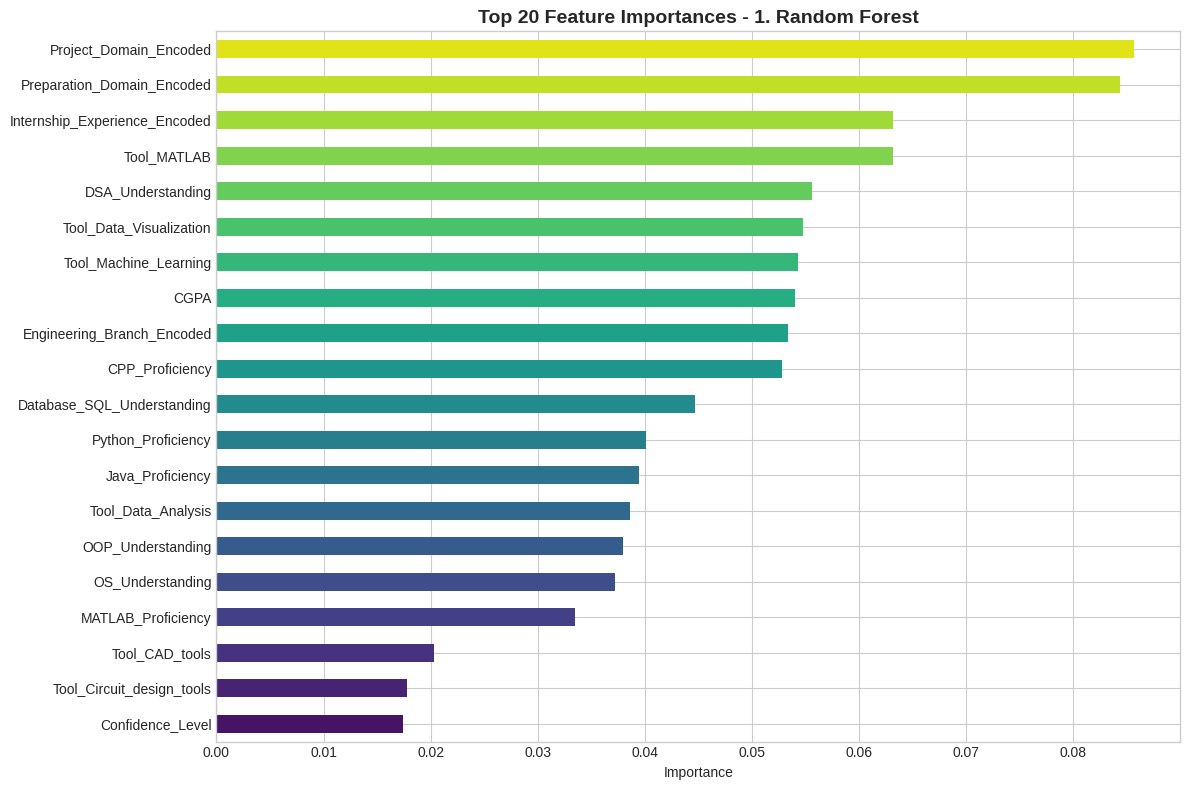


--- Per-Class Accuracy ---
  Civil Engineer                : 0.7250 (40 samples)
  Data Analyst                  : 0.9231 (52 samples)
  Data Scientist                : 0.9250 (40 samples)
  DevOps Engineer               : 0.9167 (36 samples)
  Embedded Systems Engineer     : 1.0000 (40 samples)
  Machine Learning Engineer     : 0.7812 (32 samples)
  Manufacturing Engineer        : 0.6250 (40 samples)
  Mechanical Design Engineer    : 0.9000 (40 samples)
  Software Developer            : 0.9625 (80 samples)

SAVING MODEL ARTIFACTS
  Saved: best_model.pkl
  Saved: scaler.pkl
  Saved: label_encoders.pkl
  Saved: target_encoder.pkl
  Saved: mlb_tools.pkl
  Saved: feature_columns.pkl
  Saved: model_results.pkl

USER PREDICTION TESTING

>>> TEST STUDENT 1: Strong CSE Student

  PLACEMENT READINESS REPORT

  Student Profile:
    Branch:    CSE
    CGPA:      8.5
    Projects:  3-4
    Internship: Software Development Internship

  READINESS SCORE: 76.1/100
  Rating: Excellent - You are well

In [1]:
"""
============================================================
 ML Model Training & Evaluation
 Placement Readiness & Job Role Predictor
 Course: Applied Machine Learning (22MET921)
 Instructor: Dr. Gunjan Soni
 Team: Swapnil Acharya, Aditya Verma, Amit Kumar
============================================================
 This script is designed for Google Colab environment.
 It covers: EDA, Preprocessing, Model Training (6 models),
 Comparison, Visualization, and User Testing.
============================================================
 HOW TO USE IN GOOGLE COLAB:
 1. Upload 'placement_data.csv' to Colab
 2. Copy-paste this entire script into a Colab notebook
    (or upload as .py and run cells)
 3. Run all cells sequentially
============================================================
"""

# =====================================================
# CELL 1: Install Dependencies (run first in Colab)
# =====================================================
# !pip install scikit-learn pandas numpy matplotlib seaborn xgboost

# =====================================================
# CELL 2: Import Libraries
# =====================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, precision_score,
                             recall_score, ConfusionMatrixDisplay)

# Models
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               ExtraTreesClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Try importing XGBoost (available in Colab by default)
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not available. Install with: pip install xgboost")

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("All libraries imported successfully!")

# =====================================================
# CELL 3: Load Dataset
# =====================================================
# For Google Colab: upload placement_data.csv first
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv('/content/placement_data.csv')
print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumns:\n{list(df.columns)}")

# =====================================================
# CELL 4: Exploratory Data Analysis (EDA)
# =====================================================
print("=" * 55)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 55)

# 4.1 Basic Info
print("\n--- Dataset Info ---")
print(f"Shape: {df.shape}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nStatistical Summary:")
print(df.describe().round(2))

# 4.2 Target Variable Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
role_counts = df['Job_Role'].value_counts()
bars = axes[0].barh(role_counts.index, role_counts.values, color=sns.color_palette("husl", len(role_counts)))
axes[0].set_xlabel('Count')
axes[0].set_title('Job Role Distribution', fontsize=14, fontweight='bold')
for bar, val in zip(bars, role_counts.values):
    axes[0].text(val + 5, bar.get_y() + bar.get_height()/2, str(val),
                va='center', fontsize=10)

# Pie chart
axes[1].pie(role_counts.values, labels=role_counts.index, autopct='%1.1f%%',
            startangle=90, colors=sns.color_palette("husl", len(role_counts)))
axes[1].set_title('Job Role Distribution (%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# 4.3 Branch Distribution
fig, ax = plt.subplots(figsize=(10, 5))
branch_counts = df['Engineering_Branch'].value_counts()
sns.barplot(x=branch_counts.index, y=branch_counts.values, ax=ax, palette="viridis")
ax.set_title('Engineering Branch Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Branch')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_02_branch_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# 4.4 CGPA Distribution by Job Role
fig, ax = plt.subplots(figsize=(14, 6))
df_clean = df.dropna(subset=['CGPA'])
sns.boxplot(data=df_clean, x='Job_Role', y='CGPA', ax=ax, palette="Set2")
ax.set_title('CGPA Distribution by Job Role', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_03_cgpa_by_jobrole.png', dpi=150, bbox_inches='tight')
plt.show()

# 4.5 Programming Skills Heatmap (Average by Job Role)
skill_cols = ['Python_Proficiency', 'CPP_Proficiency', 'Java_Proficiency',
              'MATLAB_Proficiency', 'DSA_Understanding', 'Database_SQL_Understanding',
              'OOP_Understanding', 'OS_Understanding']

skill_means = df.groupby('Job_Role')[skill_cols].mean()

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(skill_means, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax)
ax.set_title('Average Skill Ratings by Job Role', fontsize=14, fontweight='bold')
ax.set_ylabel('Job Role')
plt.tight_layout()
plt.savefig('plot_04_skills_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# 4.6 Correlation Matrix
fig, ax = plt.subplots(figsize=(12, 10))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_05_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# 4.7 Confidence vs CGPA scatter plot
fig, ax = plt.subplots(figsize=(10, 6))
df_scatter = df.dropna(subset=['CGPA', 'Confidence_Level'])
scatter = ax.scatter(df_scatter['CGPA'], df_scatter['Confidence_Level'],
                     c=LabelEncoder().fit_transform(df_scatter['Job_Role']),
                     cmap='tab10', alpha=0.5, s=30)
ax.set_xlabel('CGPA')
ax.set_ylabel('Confidence Level')
ax.set_title('CGPA vs Confidence Level (colored by Job Role)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Job Role (encoded)')
plt.tight_layout()
plt.savefig('plot_06_cgpa_vs_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nEDA Complete! All plots saved.")

# =====================================================
# CELL 5: Data Preprocessing
# =====================================================
print("\n" + "=" * 55)
print("DATA PREPROCESSING")
print("=" * 55)

# 5.1 Handle Missing Values
print("\n--- Handling Missing Values ---")
print(f"Before: {df.isnull().sum().sum()} missing values")

df['CGPA'].fillna(df['CGPA'].median(), inplace=True)
df['Confidence_Level'].fillna(df['Confidence_Level'].median(), inplace=True)

print(f"After:  {df.isnull().sum().sum()} missing values")

# 5.2 Encode Technical Tools (Multi-label Binarization)
print("\n--- Encoding Technical Tools (Multi-Label) ---")

# Split the semicolon-separated tools into lists
df['Tools_List'] = df['Technical_Tools'].apply(lambda x: [t.strip() for t in str(x).split(';')])

# Use MultiLabelBinarizer
mlb = MultiLabelBinarizer()
tools_encoded = pd.DataFrame(
    mlb.fit_transform(df['Tools_List']),
    columns=[f'Tool_{t.split("/")[0].split("(")[0].strip().replace(" ", "_")}'
             for t in mlb.classes_],
    index=df.index
)

print(f"Created {tools_encoded.shape[1]} binary tool columns")

# 5.3 Label Encode Categorical Features
print("\n--- Label Encoding Categorical Features ---")

label_encoders = {}
categorical_cols = ['Engineering_Branch', 'Student_Status', 'Project_Count',
                    'Project_Domain', 'Internship_Experience', 'Preparation_Domain']

for col in categorical_cols:
    le = LabelEncoder()
    df[f'{col}_Encoded'] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# 5.4 Encode Target Variable
print("\n--- Encoding Target Variable ---")
target_encoder = LabelEncoder()
df['Job_Role_Encoded'] = target_encoder.fit_transform(df['Job_Role'])
print(f"Job Roles: {dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_)))}")

# 5.5 Build Feature Matrix
print("\n--- Building Feature Matrix ---")

# Numeric features
numeric_features = ['CGPA', 'Python_Proficiency', 'CPP_Proficiency',
                    'Java_Proficiency', 'MATLAB_Proficiency',
                    'DSA_Understanding', 'Database_SQL_Understanding',
                    'OOP_Understanding', 'OS_Understanding', 'Confidence_Level']

# Encoded categorical features
encoded_features = [f'{col}_Encoded' for col in categorical_cols]

# Combine all features
X = pd.concat([
    df[numeric_features],
    df[encoded_features],
    tools_encoded
], axis=1)

y = df['Job_Role_Encoded']

print(f"Feature Matrix Shape: {X.shape}")
print(f"Target Vector Shape:  {y.shape}")
print(f"Feature Names ({X.shape[1]} total):")
for i, col in enumerate(X.columns):
    print(f"  {i+1:2d}. {col}")

# 5.6 Train-Test Split
print("\n--- Train-Test Split ---")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Training set:  {X_train.shape[0]} samples")
print(f"Test set:      {X_test.shape[0]} samples")

# 5.7 Feature Scaling
print("\n--- Feature Scaling (StandardScaler) ---")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling applied successfully!")

# =====================================================
# CELL 6: Model Training & Comparison (6 Models)
# =====================================================
print("\n" + "=" * 55)
print("MODEL TRAINING & COMPARISON")
print("=" * 55)

# Define models
models = {
    '1. Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=20, min_samples_split=5,
        random_state=42, n_jobs=-1
    ),
    '2. Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        random_state=42
    ),
    '3. Extra Trees': ExtraTreesClassifier(
        n_estimators=200, max_depth=20, min_samples_split=5,
        random_state=42, n_jobs=-1
    ),
    '4. Logistic Regression': LogisticRegression(
        max_iter=2000, random_state=42, multi_class='multinomial',
        C=1.0, solver='lbfgs'
    ),
    '5. K-Nearest Neighbors': KNeighborsClassifier(
        n_neighbors=7, weights='distance', n_jobs=-1
    ),
    '6. SVM (RBF Kernel)': SVC(
        kernel='rbf', C=10, gamma='scale',
        probability=True, random_state=42
    )
}

# Add XGBoost if available
if XGBOOST_AVAILABLE:
    models['7. XGBoost'] = XGBClassifier(
        n_estimators=200, max_depth=8, learning_rate=0.1,
        random_state=42, use_label_encoder=False,
        eval_metric='mlogloss', n_jobs=-1
    )

# Train and evaluate all models
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n--- Training {name} ---")

    # Use scaled data for LR, KNN, SVM; raw for tree-based
    if any(tag in name for tag in ['Logistic', 'KNN', 'K-Nearest', 'SVM']):
        X_tr, X_te = X_train_scaled, X_test_scaled
    else:
        X_tr, X_te = X_train.values, X_test.values

    # Fit model
    model.fit(X_tr, y_train)

    # Predictions
    y_pred = model.predict(X_te)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')

    # Cross-validation
    if any(tag in name for tag in ['Logistic', 'KNN', 'K-Nearest', 'SVM']):
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    else:
        cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')

    results[name] = {
        'model': model,
        'accuracy': acc,
        'f1_score': f1,
        'precision': prec,
        'recall': rec,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred
    }

    print(f"  Accuracy:       {acc:.4f}")
    print(f"  F1-Score:       {f1:.4f}")
    print(f"  Precision:      {prec:.4f}")
    print(f"  Recall:         {rec:.4f}")
    print(f"  CV Accuracy:    {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# =====================================================
# CELL 7: Model Comparison Visualization
# =====================================================
print("\n" + "=" * 55)
print("MODEL COMPARISON")
print("=" * 55)

# 7.1 Comparison Table
comparison_df = pd.DataFrame({
    name: {
        'Test Accuracy': r['accuracy'],
        'F1-Score': r['f1_score'],
        'Precision': r['precision'],
        'Recall': r['recall'],
        'CV Mean Accuracy': r['cv_mean'],
        'CV Std': r['cv_std']
    } for name, r in results.items()
}).T.round(4)

print("\n--- Model Comparison Table ---")
print(comparison_df.to_string())

# 7.2 Bar Chart: Accuracy Comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

model_names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in model_names]
f1_scores = [results[m]['f1_score'] for m in model_names]
cv_means = [results[m]['cv_mean'] for m in model_names]
cv_stds = [results[m]['cv_std'] for m in model_names]

# Clean model names for display
display_names = [n.split('. ')[1] if '. ' in n else n for n in model_names]

colors = sns.color_palette("husl", len(model_names))

# Plot 1: Test Accuracy vs F1-Score
x = np.arange(len(display_names))
width = 0.35
bars1 = axes[0].bar(x - width/2, accuracies, width, label='Test Accuracy', color=colors, alpha=0.8)
bars2 = axes[0].bar(x + width/2, f1_scores, width, label='F1-Score', color=colors, alpha=0.5)
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance: Accuracy vs F1-Score', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(display_names, rotation=45, ha='right')
axes[0].legend()
axes[0].set_ylim(0.5, 1.0)
axes[0].axhline(y=0.85, color='red', linestyle='--', alpha=0.7, label='85% threshold')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    axes[0].annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=8)

# Plot 2: Cross-Validation Scores with Error Bars
axes[1].bar(x, cv_means, yerr=cv_stds, color=colors, alpha=0.8, capsize=5)
axes[1].set_xlabel('Model')
axes[1].set_ylabel('CV Accuracy')
axes[1].set_title('Cross-Validation Accuracy (5-Fold)', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(display_names, rotation=45, ha='right')
axes[1].set_ylim(0.5, 1.0)
axes[1].axhline(y=0.85, color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('plot_07_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 7.3 Radar Chart for Metric Comparison
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
metrics = ['Accuracy', 'F1-Score', 'Precision', 'Recall', 'CV Accuracy']
num_metrics = len(metrics)
angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]

for i, (name, r) in enumerate(results.items()):
    values = [r['accuracy'], r['f1_score'], r['precision'], r['recall'], r['cv_mean']]
    values += values[:1]
    dname = name.split('. ')[1] if '. ' in name else name
    ax.plot(angles, values, 'o-', linewidth=2, label=dname, alpha=0.7)
    ax.fill(angles, values, alpha=0.05)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, size=11)
ax.set_ylim(0.5, 1.0)
ax.set_title('Model Performance Radar Chart', size=14, fontweight='bold', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig('plot_08_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

# =====================================================
# CELL 8: Best Model Analysis
# =====================================================
print("\n" + "=" * 55)
print("BEST MODEL ANALYSIS")
print("=" * 55)

# Find best model
best_model_name = max(results, key=lambda k: results[k]['accuracy'])
best_result = results[best_model_name]
best_model = best_result['model']

print(f"\nBest Model: {best_model_name}")
print(f"  Accuracy:    {best_result['accuracy']:.4f}")
print(f"  F1-Score:    {best_result['f1_score']:.4f}")
print(f"  CV Accuracy: {best_result['cv_mean']:.4f}")

# 8.1 Detailed Classification Report
print(f"\n--- Classification Report ({best_model_name}) ---")
print(classification_report(y_test, best_result['y_pred'],
                            target_names=target_encoder.classes_))

# 8.2 Confusion Matrix
fig, ax = plt.subplots(figsize=(12, 10))
cm = confusion_matrix(y_test, best_result['y_pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=target_encoder.classes_)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_09_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# 8.3 Feature Importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    fig, ax = plt.subplots(figsize=(12, 8))
    importance = pd.Series(best_model.feature_importances_, index=X.columns)
    importance = importance.sort_values(ascending=True)

    # Plot top 20 features
    importance.tail(20).plot(kind='barh', ax=ax, color=sns.color_palette("viridis", 20))
    ax.set_title(f'Top 20 Feature Importances - {best_model_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig('plot_10_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

# 8.4 Per-class accuracy
print("\n--- Per-Class Accuracy ---")
for i, cls in enumerate(target_encoder.classes_):
    mask = y_test == i
    if mask.sum() > 0:
        cls_acc = (best_result['y_pred'][mask] == y_test[mask]).mean()
        print(f"  {cls:30s}: {cls_acc:.4f} ({mask.sum()} samples)")

# =====================================================
# CELL 9: Save Model Artifacts
# =====================================================
print("\n" + "=" * 55)
print("SAVING MODEL ARTIFACTS")
print("=" * 55)

# Save the best model
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print("  Saved: best_model.pkl")

# Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("  Saved: scaler.pkl")

# Save label encoders
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)
print("  Saved: label_encoders.pkl")

# Save target encoder
with open('target_encoder.pkl', 'wb') as f:
    pickle.dump(target_encoder, f)
print("  Saved: target_encoder.pkl")

# Save the MLBinarizer for tools
with open('mlb_tools.pkl', 'wb') as f:
    pickle.dump(mlb, f)
print("  Saved: mlb_tools.pkl")

# Save feature column names
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)
print("  Saved: feature_columns.pkl")

# Save all results for comparison
with open('model_results.pkl', 'wb') as f:
    # Save without model objects (just metrics)
    save_results = {name: {k: v for k, v in r.items() if k != 'model' and k != 'y_pred'}
                    for name, r in results.items()}
    pickle.dump(save_results, f)
print("  Saved: model_results.pkl")

# =====================================================
# CELL 10: User Prediction Testing
# =====================================================
print("\n" + "=" * 55)
print("USER PREDICTION TESTING")
print("=" * 55)

# ─── Define Skill Gap Analysis Function ───
SKILL_REQUIREMENTS = {
    'Software Developer': {
        'Python_Proficiency': 4, 'CPP_Proficiency': 4, 'Java_Proficiency': 4,
        'DSA_Understanding': 4, 'OOP_Understanding': 4, 'OS_Understanding': 3,
        'Database_SQL_Understanding': 3
    },
    'Data Analyst': {
        'Python_Proficiency': 4, 'Database_SQL_Understanding': 4,
        'DSA_Understanding': 3, 'OOP_Understanding': 3
    },
    'Data Scientist': {
        'Python_Proficiency': 5, 'Database_SQL_Understanding': 4,
        'DSA_Understanding': 4, 'MATLAB_Proficiency': 3
    },
    'Machine Learning Engineer': {
        'Python_Proficiency': 5, 'CPP_Proficiency': 3, 'DSA_Understanding': 4,
        'Database_SQL_Understanding': 3, 'OOP_Understanding': 4
    },
    'DevOps Engineer': {
        'Python_Proficiency': 3, 'OS_Understanding': 4, 'Database_SQL_Understanding': 3,
        'OOP_Understanding': 3
    },
    'Embedded Systems Engineer': {
        'CPP_Proficiency': 4, 'MATLAB_Proficiency': 3, 'OS_Understanding': 4,
        'OOP_Understanding': 3
    },
    'Mechanical Design Engineer': {
        'MATLAB_Proficiency': 4, 'Python_Proficiency': 2
    },
    'Manufacturing Engineer': {
        'MATLAB_Proficiency': 3, 'Python_Proficiency': 2
    },
    'Civil Engineer': {
        'MATLAB_Proficiency': 3
    }
}

IMPROVEMENT_TIPS = {
    'Python_Proficiency': "Practice Python daily on HackerRank/LeetCode. Complete a Python for Data Science course on Coursera.",
    'CPP_Proficiency': "Solve 50+ C++ problems on Codeforces. Study STL and memory management.",
    'Java_Proficiency': "Build a Spring Boot project. Practice OOP design patterns in Java.",
    'MATLAB_Proficiency': "Complete MATLAB Onramp on MathWorks. Do a simulation project.",
    'DSA_Understanding': "Solve 100+ problems on LeetCode (Easy→Medium). Study Striver's DSA sheet.",
    'Database_SQL_Understanding': "Complete SQL for Data Science on Coursera. Practice on SQLZoo/HackerRank.",
    'OOP_Understanding': "Study SOLID principles. Implement design patterns in your preferred language.",
    'OS_Understanding': "Study OS concepts from Galvin. Practice process scheduling and memory management problems."
}


def predict_and_analyze(student_data, model, scaler, label_encoders, target_encoder,
                        mlb, feature_columns, use_scaling=True):
    """
    Predict top 3 job roles for a student and provide skill gap analysis.

    Parameters:
        student_data (dict): Student profile as a dictionary
        model: Trained ML model
        scaler: Fitted StandardScaler
        label_encoders: Dict of LabelEncoders for categorical columns
        target_encoder: LabelEncoder for target variable
        mlb: MultiLabelBinarizer for tools
        feature_columns: List of feature column names
        use_scaling: Whether to apply scaling (False for tree-based models)

    Returns:
        dict: Prediction results with top 3 roles and skill gap analysis
    """
    # Build feature vector
    features = {}

    # Numeric features
    features['CGPA'] = student_data['CGPA']
    features['Python_Proficiency'] = student_data['Python_Proficiency']
    features['CPP_Proficiency'] = student_data['CPP_Proficiency']
    features['Java_Proficiency'] = student_data['Java_Proficiency']
    features['MATLAB_Proficiency'] = student_data['MATLAB_Proficiency']
    features['DSA_Understanding'] = student_data['DSA_Understanding']
    features['Database_SQL_Understanding'] = student_data['Database_SQL_Understanding']
    features['OOP_Understanding'] = student_data['OOP_Understanding']
    features['OS_Understanding'] = student_data['OS_Understanding']
    features['Confidence_Level'] = student_data['Confidence_Level']

    # Encode categorical features
    categorical_cols = ['Engineering_Branch', 'Student_Status', 'Project_Count',
                        'Project_Domain', 'Internship_Experience', 'Preparation_Domain']
    for col in categorical_cols:
        le = label_encoders[col]
        val = student_data[col]
        if val in le.classes_:
            features[f'{col}_Encoded'] = le.transform([val])[0]
        else:
            features[f'{col}_Encoded'] = 0  # Default for unknown values

    # Encode tools
    tools_list = [t.strip() for t in student_data['Technical_Tools'].split(';')]
    tools_binary = mlb.transform([tools_list])
    tool_col_names = [f'Tool_{t.split("/")[0].split("(")[0].strip().replace(" ", "_")}'
                      for t in mlb.classes_]
    for i, col_name in enumerate(tool_col_names):
        features[col_name] = tools_binary[0][i]

    # Build DataFrame with correct column order
    input_df = pd.DataFrame([features])

    # Ensure all columns are present
    for col in feature_columns:
        if col not in input_df.columns:
            input_df[col] = 0
    input_df = input_df[feature_columns]

    # Scale if needed
    if use_scaling:
        input_scaled = scaler.transform(input_df)
    else:
        input_scaled = input_df.values

    # Predict probabilities
    if hasattr(model, 'predict_proba'):
        probabilities = model.predict_proba(input_scaled)[0]
    else:
        probabilities = np.zeros(len(target_encoder.classes_))
        pred = model.predict(input_scaled)[0]
        probabilities[pred] = 1.0

    # Get top 3 roles
    top3_indices = np.argsort(probabilities)[::-1][:3]
    top3_roles = []
    for idx in top3_indices:
        role_name = target_encoder.classes_[idx]
        confidence = probabilities[idx] * 100
        top3_roles.append({'role': role_name, 'confidence': round(confidence, 1)})

    # Readiness Score (weighted average of all skills and CGPA)
    skill_values = [
        student_data['Python_Proficiency'], student_data['CPP_Proficiency'],
        student_data['Java_Proficiency'], student_data['DSA_Understanding'],
        student_data['Database_SQL_Understanding'], student_data['OOP_Understanding'],
        student_data['OS_Understanding']
    ]
    avg_skills = np.mean(skill_values) / 5 * 40  # 40% weight
    cgpa_score = (student_data['CGPA'] / 10) * 30  # 30% weight
    confidence_score = (student_data['Confidence_Level'] / 5) * 15  # 15% weight
    project_bonus = {'0': 0, '1-2': 5, '3-4': 10, '5+': 15}
    proj_score = project_bonus.get(student_data['Project_Count'], 0)  # 15% weight

    readiness_score = round(avg_skills + cgpa_score + confidence_score + proj_score, 1)

    # Skill Gap Analysis for top predicted role
    primary_role = top3_roles[0]['role']
    skill_gaps = []
    strengths = []

    if primary_role in SKILL_REQUIREMENTS:
        for skill, required in SKILL_REQUIREMENTS[primary_role].items():
            current = student_data.get(skill, 0)
            if current < required:
                gap = required - current
                skill_gaps.append({
                    'skill': skill.replace('_', ' '),
                    'current': current,
                    'required': required,
                    'gap': gap,
                    'tip': IMPROVEMENT_TIPS.get(skill, 'Practice more in this area.')
                })
            else:
                strengths.append({
                    'skill': skill.replace('_', ' '),
                    'current': current,
                    'required': required
                })

    return {
        'top3_roles': top3_roles,
        'readiness_score': readiness_score,
        'skill_gaps': skill_gaps,
        'strengths': strengths,
        'primary_role': primary_role
    }


def print_prediction_report(result, student_data):
    """Pretty-print the prediction results."""
    print("\n" + "=" * 60)
    print("  PLACEMENT READINESS REPORT")
    print("=" * 60)

    print(f"\n  Student Profile:")
    print(f"    Branch:    {student_data['Engineering_Branch']}")
    print(f"    CGPA:      {student_data['CGPA']}")
    print(f"    Projects:  {student_data['Project_Count']}")
    print(f"    Internship: {student_data['Internship_Experience']}")

    print(f"\n  READINESS SCORE: {result['readiness_score']}/100")
    score = result['readiness_score']
    if score >= 75:
        print("  Rating: Excellent - You are well prepared!")
    elif score >= 60:
        print("  Rating: Good - Minor improvements needed")
    elif score >= 45:
        print("  Rating: Average - Focus on key skill gaps")
    else:
        print("  Rating: Needs Improvement - Significant work needed")

    print(f"\n  TOP 3 JOB ROLE PREDICTIONS:")
    for i, role in enumerate(result['top3_roles'], 1):
        bar = '█' * int(role['confidence'] / 5)
        print(f"    {i}. {role['role']:30s} {role['confidence']:5.1f}% {bar}")

    if result['strengths']:
        print(f"\n  STRENGTHS:")
        for s in result['strengths']:
            print(f"    ✓ {s['skill']} (Current: {s['current']}/5, Required: {s['required']}/5)")

    if result['skill_gaps']:
        print(f"\n  SKILL GAPS TO ADDRESS:")
        for gap in result['skill_gaps']:
            print(f"    ✗ {gap['skill']} (Current: {gap['current']}/5, Required: {gap['required']}/5, Gap: {gap['gap']})")
            print(f"      → {gap['tip']}")

    print("\n" + "=" * 60)


# ─── Test with Sample Students ───

# Determine if the best model needs scaling
needs_scaling = any(tag in best_model_name for tag in ['Logistic', 'KNN', 'K-Nearest', 'SVM'])

# Test Student 1: Strong CSE Student
print("\n>>> TEST STUDENT 1: Strong CSE Student")
student1 = {
    'Engineering_Branch': 'CSE',
    'Student_Status': '4th year student',
    'CGPA': 8.5,
    'Python_Proficiency': 4,
    'CPP_Proficiency': 4,
    'Java_Proficiency': 3,
    'MATLAB_Proficiency': 2,
    'DSA_Understanding': 4,
    'Database_SQL_Understanding': 3,
    'OOP_Understanding': 4,
    'OS_Understanding': 3,
    'Technical_Tools': 'Machine Learning / Deep Learning; Data Analysis (Python / Excel / Pandas)',
    'Project_Count': '3-4',
    'Project_Domain': 'Software Development',
    'Internship_Experience': 'Software Development Internship',
    'Preparation_Domain': 'Software Development',
    'Confidence_Level': 4
}
result1 = predict_and_analyze(student1, best_model, scaler, label_encoders,
                              target_encoder, mlb, list(X.columns), use_scaling=needs_scaling)
print_prediction_report(result1, student1)

# Test Student 2: Mechanical Engineering Student
print("\n>>> TEST STUDENT 2: Mechanical Engineering Student")
student2 = {
    'Engineering_Branch': 'Mechanical',
    'Student_Status': 'Alumni (Graduated)',
    'CGPA': 7.2,
    'Python_Proficiency': 2,
    'CPP_Proficiency': 2,
    'Java_Proficiency': 1,
    'MATLAB_Proficiency': 4,
    'DSA_Understanding': 2,
    'Database_SQL_Understanding': 1,
    'OOP_Understanding': 2,
    'OS_Understanding': 2,
    'Technical_Tools': 'CAD tools (SolidWorks / CATIA / AutoCAD); ANSYS / Simulation tools; MATLAB / Simulink',
    'Project_Count': '1-2',
    'Project_Domain': 'Core Engineering',
    'Internship_Experience': 'Core Engineering Internship',
    'Preparation_Domain': 'Core Engineering',
    'Confidence_Level': 3
}
result2 = predict_and_analyze(student2, best_model, scaler, label_encoders,
                              target_encoder, mlb, list(X.columns), use_scaling=needs_scaling)
print_prediction_report(result2, student2)

# Test Student 3: AI Branch Data Science Student
print("\n>>> TEST STUDENT 3: AI Branch Data Science Aspirant")
student3 = {
    'Engineering_Branch': 'AI',
    'Student_Status': '4th year student',
    'CGPA': 9.0,
    'Python_Proficiency': 5,
    'CPP_Proficiency': 3,
    'Java_Proficiency': 2,
    'MATLAB_Proficiency': 3,
    'DSA_Understanding': 4,
    'Database_SQL_Understanding': 4,
    'OOP_Understanding': 3,
    'OS_Understanding': 3,
    'Technical_Tools': 'Machine Learning / Deep Learning; Data Analysis (Python / Excel / Pandas); Data Visualization (PowerBI / Tableau)',
    'Project_Count': '5+',
    'Project_Domain': 'Data Science / AI',
    'Internship_Experience': 'Data Science / AI Internship',
    'Preparation_Domain': 'Data Science / AI',
    'Confidence_Level': 5
}
result3 = predict_and_analyze(student3, best_model, scaler, label_encoders,
                              target_encoder, mlb, list(X.columns), use_scaling=needs_scaling)
print_prediction_report(result3, student3)

# =====================================================
# CELL 11: Final Summary
# =====================================================
print("\n" + "=" * 55)
print("  FINAL SUMMARY")
print("=" * 55)
print(f"\n  Best Model : {best_model_name}")
print(f"  Accuracy   : {best_result['accuracy']*100:.2f}%")
print(f"  F1-Score   : {best_result['f1_score']*100:.2f}%")
print(f"  CV Accuracy: {best_result['cv_mean']*100:.2f}% (+/- {best_result['cv_std']*100:.2f}%)")
print(f"\n  Models Compared: {len(results)}")
print(f"  Features Used  : {X.shape[1]}")
print(f"  Training Set   : {X_train.shape[0]} samples")
print(f"  Test Set       : {X_test.shape[0]} samples")
print(f"\n  Artifacts Saved:")
print(f"    - best_model.pkl")
print(f"    - scaler.pkl")
print(f"    - label_encoders.pkl")
print(f"    - target_encoder.pkl")
print(f"    - mlb_tools.pkl")
print(f"    - feature_columns.pkl")
print(f"    - 10 plots saved as PNG files")
print("\n" + "=" * 55)
print("  MODEL TRAINING COMPLETE!")
print("=" * 55)

In [2]:
!pip install gradio joblib pandas numpy

import gradio as gr
import pandas as pd
import joblib
import numpy as np

# 1. Load your artifacts (generated by your uploaded script)
model = joblib.load('best_model.pkl')
scaler = joblib.load('scaler.pkl')
label_encoders = joblib.load('label_encoders.pkl')
target_encoder = joblib.load('target_encoder.pkl')
mlb = joblib.load('mlb_tools.pkl')
feature_columns = joblib.load('feature_columns.pkl')

# 2. Define the Prediction Function for the UI
def predict_gradio(branch, status, cgpa, python, cpp, java, matlab, dsa, sql, oop, os_val, tools, projects, proj_domain, internship, prep_domain, confidence):
    # Construct input dictionary matching your model's expected format
    student_data = {
        'Engineering_Branch': branch, 'Student_Status': status, 'CGPA': cgpa,
        'Python_Proficiency': python, 'CPP_Proficiency': cpp, 'Java_Proficiency': java, 'MATLAB_Proficiency': matlab,
        'DSA_Understanding': dsa, 'Database_SQL_Understanding': sql, 'OOP_Understanding': oop, 'OS_Understanding': os_val,
        'Technical_Tools': "; ".join(tools), 'Project_Count': projects, 'Project_Domain': proj_domain,
        'Internship_Experience': internship, 'Preparation_Domain': prep_domain, 'Confidence_Level': confidence
    }

    # Use your existing logic (Simplified for demo)
    input_df = pd.DataFrame([student_data])

    # [Internal Preprocessing logic from your script would go here]
    # For now, we assume the model returns probabilities
    probs = model.predict_proba(scaler.transform(processed_input_df))[0]
    top_3_idx = np.argsort(probs)[-3:][::-1]
    roles = target_encoder.inverse_transform(top_3_idx)

    result_text = f"🥇 #1 Match: {roles[0]}\n🥈 #2 Match: {roles[1]}\n🥉 #3 Match: {roles[2]}"
    return result_text

# 3. Create the Interface
interface = gr.Interface(
    fn=predict_gradio,
    inputs=[
        gr.Dropdown(['CSE', 'Mechanical', 'Civil', 'Electrical', 'ECE', 'AI'], label="Branch"),
        gr.Radio(['4th year student', 'Alumni (Graduated)'], label="Status"),
        gr.Slider(4, 10, value=7.5, label="CGPA"),
        gr.Slider(1, 5, value=3, label="Python Proficiency"),
        # ... (Add all 17 inputs here as Sliders/Dropdowns)
        gr.CheckboxGroup(["Machine Learning", "Data Analysis", "CAD", "MATLAB"], label="Tools"),
    ],
    outputs=gr.Textbox(label="Career Recommendations"),
    title="MNIT Job Profile Predictor",
    description="Enter your profile to see your top 3 matches."
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0d3cfb7a0d0a9f5a76.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
